In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import bisect 
import h5py
import h5py

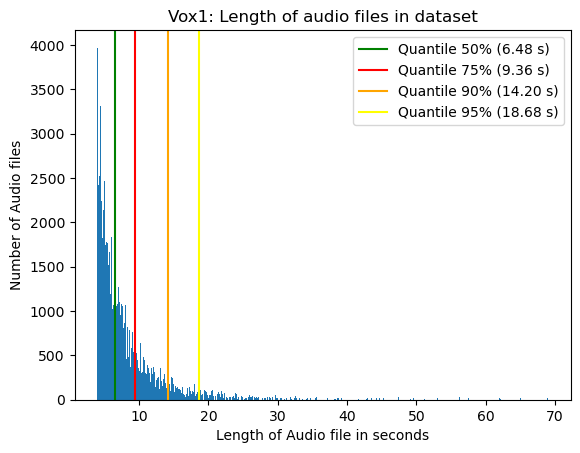

In [69]:
x = np.load("/mnt/ssd2/Tassi/TassiMA/Figures/Vox1_audio_lengths.npy")
x = x/16000
save_path = "/mnt/ssd2/Tassi/TassiMA/Figures"
x.sort()
quantil_50 = x[len(x)//2].item()
quantil_75 = x[len(x)*3//4].item()
quantil_90 = x[len(x)*9//10].item()
quantil_95 = x[len(x)*19//20].item()
cut = 63488
index = bisect.bisect_right(x, cut)

plt.figure()
plt.title("Vox1: Length of audio files in dataset")
plt.hist(x, bins=500)

plt.axvline(x = quantil_50, color="green", label = "Quantile 50% ("+"%.2f s"%quantil_50+")")
plt.axvline(x = quantil_75, color="red", label = "Quantile 75% ("+"%.2f s"%quantil_75+")")
plt.axvline(x = quantil_90, color="orange", label = "Quantile 90% ("+"%.2f s"%quantil_90+")")
plt.axvline(x = quantil_95, color="yellow", label= "Quantile 95% ("+"%.2f s"%quantil_95+")")
plt.legend()
plt.xlabel("Length of Audio file in seconds")
plt.ylabel("Number of Audio files")
plt.savefig(os.path.join(save_path,"Vox1_audiofile_length_in_dataset_full.pdf"))
plt.show()

# plt.figure()
# plt.title("Vox2: Length of audio files in dataset")
# plt.hist(x, bins=500)

# # plt.axvline(x = cut, color="black", label = f'Quantile 30% ({index} samples)')
# plt.axvline(x = quantil_50, color="green", label = "Quantile 50% ("+"%.2f s"%quantil_50+")")
# plt.axvline(x = quantil_75, color="red", label = "Quantile 75% ("+"%.2f s"%quantil_75+")")
# plt.axvline(x = quantil_90, color="orange", label = "Quantile 90% ("+"%.2f s"%quantil_90+")")
# plt.axvline(x = quantil_95, color="yellow", label= "Quantile 95% ("+"%.2f s"%quantil_95+")")
# plt.legend()
# plt.xlabel("Length of Audio file in seconds")
# plt.ylabel("Number of Audio files")
# plt.xlim(0, 50)
# plt.savefig(os.path.join(save_path,"Vox2_audiofile_length_in_dataset_xlim.pdf"))
# plt.show()


In [2]:
vox2 = h5py.File("/mnt/ssd2/Tassi/TassiMA/Voxceleb_data/SpeakerDataVox2.hdf5", "r")

# list_speaker = []
# for key in vox2.keys():
#     list_speaker.append(len(vox2[key].keys()))

In [8]:
vox2['speaker_1']['utterance_7']

<HDF5 dataset "utterance_7": shape (63488,), type "<f4">

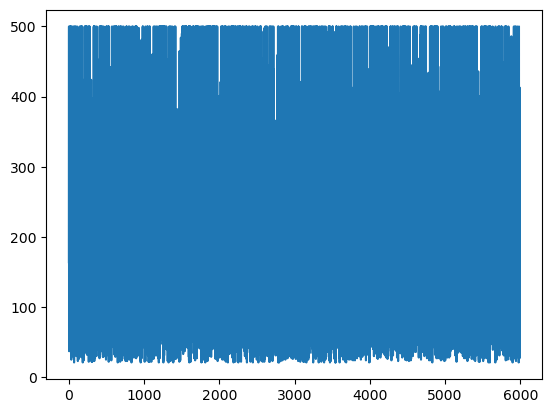

In [10]:
plt.plot(list_speaker)

/tmp/ipykernel_4550/4007718380.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


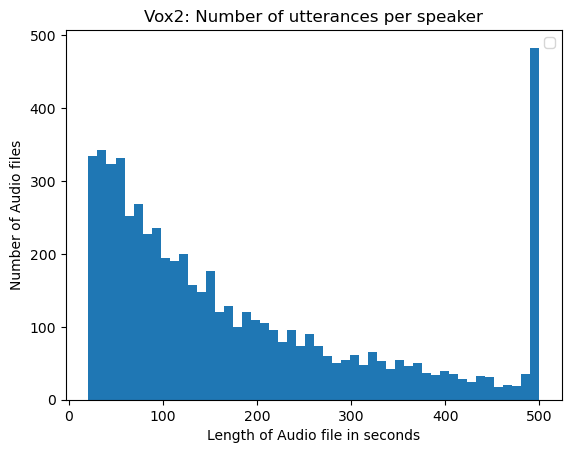

In [15]:

plt.figure()
plt.title("Vox2: Number of utterances per speaker")
plt.hist(list_speaker, bins=50)

plt.legend()
plt.xlabel("Length of Audio file in seconds")
plt.ylabel("Number of Audio files")
# plt.savefig(os.path.join(save_path,"Vox1_audiofile_length_in_dataset_full.pdf"))
plt.show()

# plt.figure()
# plt.title("Vox2: Length of audio files in dataset")
# plt.hist(x, bins=500)

# # plt.axvline(x = cut, color="black", label = f'Quantile 30% ({index} samples)')
# plt.axvline(x = quantil_50, color="green", label = "Quantile 50% ("+"%.2f s"%quantil_50+")")
# plt.axvline(x = quantil_75, color="red", label = "Quantile 75% ("+"%.2f s"%quantil_75+")")
# plt.axvline(x = quantil_90, color="orange", label = "Quantile 90% ("+"%.2f s"%quantil_90+")")
# plt.axvline(x = quantil_95, color="yellow", label= "Quantile 95% ("+"%.2f s"%quantil_95+")")
# plt.legend()
# plt.xlabel("Length of Audio file in seconds")
# plt.ylabel("Number of Audio files")
# plt.xlim(0, 50)
# plt.savefig(os.path.join(save_path,"Vox2_audiofile_length_in_dataset_xlim.pdf"))
# plt.show()


In [31]:
index

31487

In [28]:
index/len(x)

0.028834011441297644

In [37]:

class GetAudioVox1():
    def __init__(self, train_list, max_frames, train_path, **kwargs):


        self.train_list = train_list
        self.max_frames = max_frames 
        # self.non_working_indices = []
        
        # Read training files
        with open(train_list) as dataset_file:
            lines = dataset_file.readlines() 

        # Make a dictionary of ID names and ID indices
        dictkeys = list(set([x.split()[0] for x in lines]))
        dictkeys.sort()
        dictkeys = { key : ii for ii, key in enumerate(dictkeys) }

        # Parse the training list into file names and ID indices
        self.data_list  = []
        self.data_label = []
        
        for lidx, line in enumerate(lines):
            data = line.strip().split() 

            speaker_label = dictkeys[data[0]] 
            filename = os.path.join(train_path,data[1]) 
            
            self.data_label.append(speaker_label)
            self.data_list.append(filename)


In [39]:
def getAudioVox1():   
    Audio = GetAudioVox1(
        train_list = "/mnt/Games/Tassia_Daten/vox2/test_list.txt", 
        max_frames = 200,
        train_path = "/mnt/Games/Tassia_Daten/vox1/voxceleb1")
    return Audio

getAudioVox1()


In [40]:
def refactor_test_list():
    with open("/mnt/Games/Tassia_Daten/vox2/test_list.txt") as f:
        lines = f.readlines()
    with open("/mnt/Games/Tassia_Daten/vox2/test_list_refactored.txt", "w") as f:
        for line in lines:
            split = line.split()
            audio1 = split[1]
            speaker1 = audio1.split("/")[0]
            audio2 = split[2]
            speaker2 = audio2.split("/")[0]
            f.write(f"{speaker1} {audio1}\n")
            f.write(f"{speaker2} {audio2}\n")

In [41]:
refactor_test_list()

In [70]:
63488/16000

3.968

In [74]:
from pptree import Node, print_tree
import h5py

In [14]:
f = h5py.File("/mnt/ssd2/Tassi/TassiMA/Voxceleb_data/SpeakerDataVox1.hdf5", "r")

In [6]:
def print_hdf5(file):
    """
    Print the structure of the hdf5 file

    Args:
        file (str): path to the hdf5 file
    """
    def traverse(stem, grp):
        for key in list(grp):

            if isinstance(grp[key], h5py.Group):
                thisnode = Node(key, stem)
                traverse(thisnode, grp[key])

            elif isinstance(grp[key], h5py.Dataset):
                thisnode = Node(f"{key} {str(grp[key].shape)} {str(grp[key].dtype)}", stem)
    print(f"File: {file}")
    root = Node('root')
    file = h5py.File(file, "r")
    traverse(root, file)
    print_tree(root)

In [8]:
print_hdf5("/mnt/ssd2/Tassi/TassiMA/Voxceleb_data/SpeakerDataVox2.hdf5")

File: /mnt/ssd2/Tassi/TassiMA/Voxceleb_data/SpeakerDataVox2.hdf5


NameError: name 'Node' is not defined

Number of utterances: 75222


37611.0

Number of speakers: 40


np.int64(3480)

3479

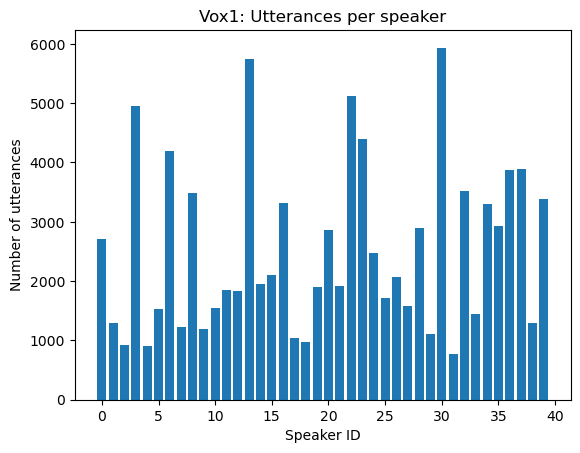

In [100]:
num_utterances = []
with h5py.File("/mnt/Games/Tassia_Daten/SpeakerDataVox1.hdf5", "r") as f:
    for idx in range(len(f.keys())):
        num_utterances.append(f['speaker_'+str(idx)].attrs['num_utterances'].item())
    plt.bar(x=np.arange(0, len(f.keys()),1),height=num_utterances)
    plt.title("Vox1: Utterances per speaker")
    plt.xlabel("Speaker ID")
    plt.ylabel("Number of utterances")
    # plt.savefig("/mnt/ssd2/Tassi/TassiMA/Figures/Vox1_utterances_per_speaker.pdf")

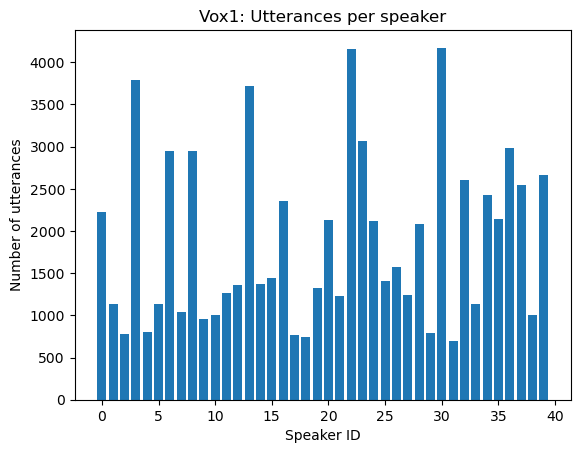

In [102]:
num_utterances = []
with h5py.File("/mnt/Games/Tassia_Daten/SpeakerDataVox1.hdf5", "r") as f:
    for idx in range(len(f.keys())):
        num_utterances.append(f['speaker_'+str(idx)].attrs['num_utterances'].item())
    plt.bar(x=np.arange(0, len(f.keys()),1),height=num_utterances)
    plt.title("Vox1: Utterances per speaker")
    plt.xlabel("Speaker ID")
    plt.ylabel("Number of utterances")
    plt.savefig("/mnt/ssd2/Tassi/TassiMA/Figures/Vox1_utterances_per_speaker.pdf")

In [11]:

with h5py.File("/mnt/ssd2/Tassi/TassiMA/Voxceleb_data/SpeakerDataVox1.hdf5", "r") as f:
    print("hi")
    for idx in range(len(f.keys())):
        x = f['speaker_'+str(idx)].attrs['num_utterances'].item()
        print(x, " , ", len(f['speaker_'+str(idx)].keys()))

hi
2227  ,  2227
1137  ,  1137
775  ,  775
3784  ,  3784
803  ,  803
1138  ,  1138
2949  ,  2949
1038  ,  1038
2946  ,  2946
954  ,  954
1001  ,  1001
1264  ,  1264
1357  ,  1357
3714  ,  3714
1372  ,  1372
1447  ,  1447
2356  ,  2356
771  ,  771
745  ,  745
1322  ,  1322
2131  ,  2131
1234  ,  1234
4156  ,  4156
3060  ,  3060
2119  ,  2119
1407  ,  1407
1573  ,  1573
1241  ,  1241
2077  ,  2077
787  ,  787
4171  ,  4171
691  ,  691
2602  ,  2602
1135  ,  1135
2423  ,  2423
2139  ,  2139
2980  ,  2980
2539  ,  2539
999  ,  999
2658  ,  2658


In [3]:
x = []
with h5py.File("/mnt/ssd2/Tassi/TassiMA/Voxceleb_data/SpeakerDataVox1.hdf5", "r") as f:
    for idx in range(len(f.keys())):
        x.append(f['speaker_'+str(idx)].attrs['num_utterances'].item())


with h5py.File("/mnt/ssd2/Tassi/TassiMA/Voxceleb_data/SpeakerDataVox1.hdf5", "w") as f:
    for i,idx in enumerate(range(len(f.keys()))):
       f['speaker_'+str(idx)].attrs['num_utterances'] = x[i]

In [24]:
f = h5py.File("/mnt/ssd2/Tassi/TassiMA/Voxceleb_data/SpeakerDataVox2_test.hdf5", "r")

In [7]:
f.keys()

<KeysViewHDF5 []>

In [10]:

with h5py.File("/mnt/Games/Tassia_Daten/SpeakerDataVox1.hdf5", "r") as f:
    print("hi")
    for idx in range(len(f.keys())):
        x = f['speaker_'+str(idx)].attrs['num_utterances'].item()
        print(x, " , ", len(f['speaker_'+str(idx)].keys()))

hi
2228  ,  2227
1138  ,  1137
776  ,  775
3785  ,  3784
804  ,  803
1139  ,  1138
2950  ,  2949
1039  ,  1038
2947  ,  2946
955  ,  954
1002  ,  1001
1265  ,  1264
1358  ,  1357


KeyboardInterrupt: 

## New stuff

In [ ]:

with open("/mnt/Games/Tassia_Daten/vox2/test_list_refactored.txt") as dataset_file:
    lines = dataset_file.readlines() 

dictkeys = list(set([x.split()[0] for x in lines]))

In [21]:
len(dictkeys)

40

In [23]:
len(lines)

75222

In [25]:
f = h5py.File("/mnt/ssd2/Tassi/TassiMA/Voxceleb_data/SpeakerDataVox2_test.hdf5", "r")
speakers = len(f.keys())
print(f"Number of speakers: {speakers}")
utterances = 0
for k in f.keys():
    utterances += len(list(f[k].keys()))
print(f"Number of utterances: {utterances}")

Number of speakers: 118
Number of utterances: 36237


In [ ]:
import glob
speakers2 = {}
total2 = 0
with open("/mnt/Games/Tassia_Daten/vox2/test_list_refactored.txt") as lines:
    for line in lines:
        id = line.split(" ")[0]
        path = "/mnt/Games/Tassia_Daten/vox1/voxceleb1/"+id+"/*/*.wav"
        files = glob.glob(path)
        total2 += len(files)
        if id not in speakers2:
            speakers2[id] = len(files)
        else:
            speakers2[id] += len(files)

In [ ]:

print(f"Speaker {id} has {len(files)} utterances")

In [28]:
total

11718888

In [29]:
len(list(speakers.keys()))

40